# Field SMF 01b · Quiescent field stellar mass function

Same 1/V_max procedure as `00_FieldSMF_total.ipynb`, applied to the quiescent subset of the field sample (Dn4000 ≥ 1.5).

**Input**: `DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv` (not included)

**Output**: `FieldSMF_quiescent.csv` – used by `02_FieldSMF_Comparison_and_fq.ipynb` and `MACH/SMF/04_SMF_starforming_quiescent_compare.ipynb`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [2]:
# Read galaxy catalog
df0 = pd.read_csv(f'{MAINPATH}/DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv')

# ----- Spectroscopic Completeness by Magnitude -----

# Set up magnitude bins (r-band, 0.25 mag width, from 5 to 20)
bin_edges = np.arange(5, 20.25, 0.25)
bin_labels = bin_edges[:-1] + 0.05  # bin centers

# Bin galaxies by apparent r magnitude
df0['mag_bin'] = pd.cut(
    df0['petroMag_r'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

# Group galaxies by these bins
grouped = df0.groupby('mag_bin')

# Count total objects per bin
total_counts = grouped.size()

# Count objects with valid redshift (z != -99) per bin
valid_counts = grouped['z'].apply(lambda series: (series != -99).sum())

# Compute spectroscopic completeness (fraction with z per magnitude bin)
completeness = valid_counts / total_counts

# Avoid invalid weights by replacing 0 completeness with NaN
completeness.replace(0, np.nan, inplace=True)

# Assign spectroscopic weight: w_spec = 1 / completeness (mapped back to DataFrame)
df0['w_spec'] = df0['mag_bin'].map(lambda binval: 1 / completeness.get(binval, np.nan))

# Remove temporary bin column
df0.drop(columns='mag_bin', inplace=True)

# ----- Calculate Absolute Magnitude -----

# Correct r-band magnitude for extinction
df0['petroMag_r_0'] = df0['petroMag_r'] - df0['extinction_r']
# Compute absolute r mag using the cosmology for each redshift
df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)

# --- Select clean field quiescent sample ---

# Define quiescent: Dn4000 >= 1.5 and valid
quiescent_mask = (df0['Dn4000'] >= 1.5) & (df0['Dn4000'] != -99)

# Select 0.07 < z < 0.11 and quiescent
field_sample = df0[(df0['z'] > 0.07) & (df0['z'] < 0.11) & quiescent_mask]

# Only keep rows with valid stellar mass
field_sample = field_sample[field_sample['M_MASS_CIGALE'] != -99]

df = field_sample.copy()

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21643/1633795339.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df0.groupby('mag_bin')
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21643/1633795339.py:47: RuntimeWarning: divide by zero encountered in log10
  df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_21643/1633795339.py:47: RuntimeWarning: invalid value encountered in log10
  df0['AbsMag_r'] = df0['petroMag_r_0

# 1. Make (field, quiescent) SMF

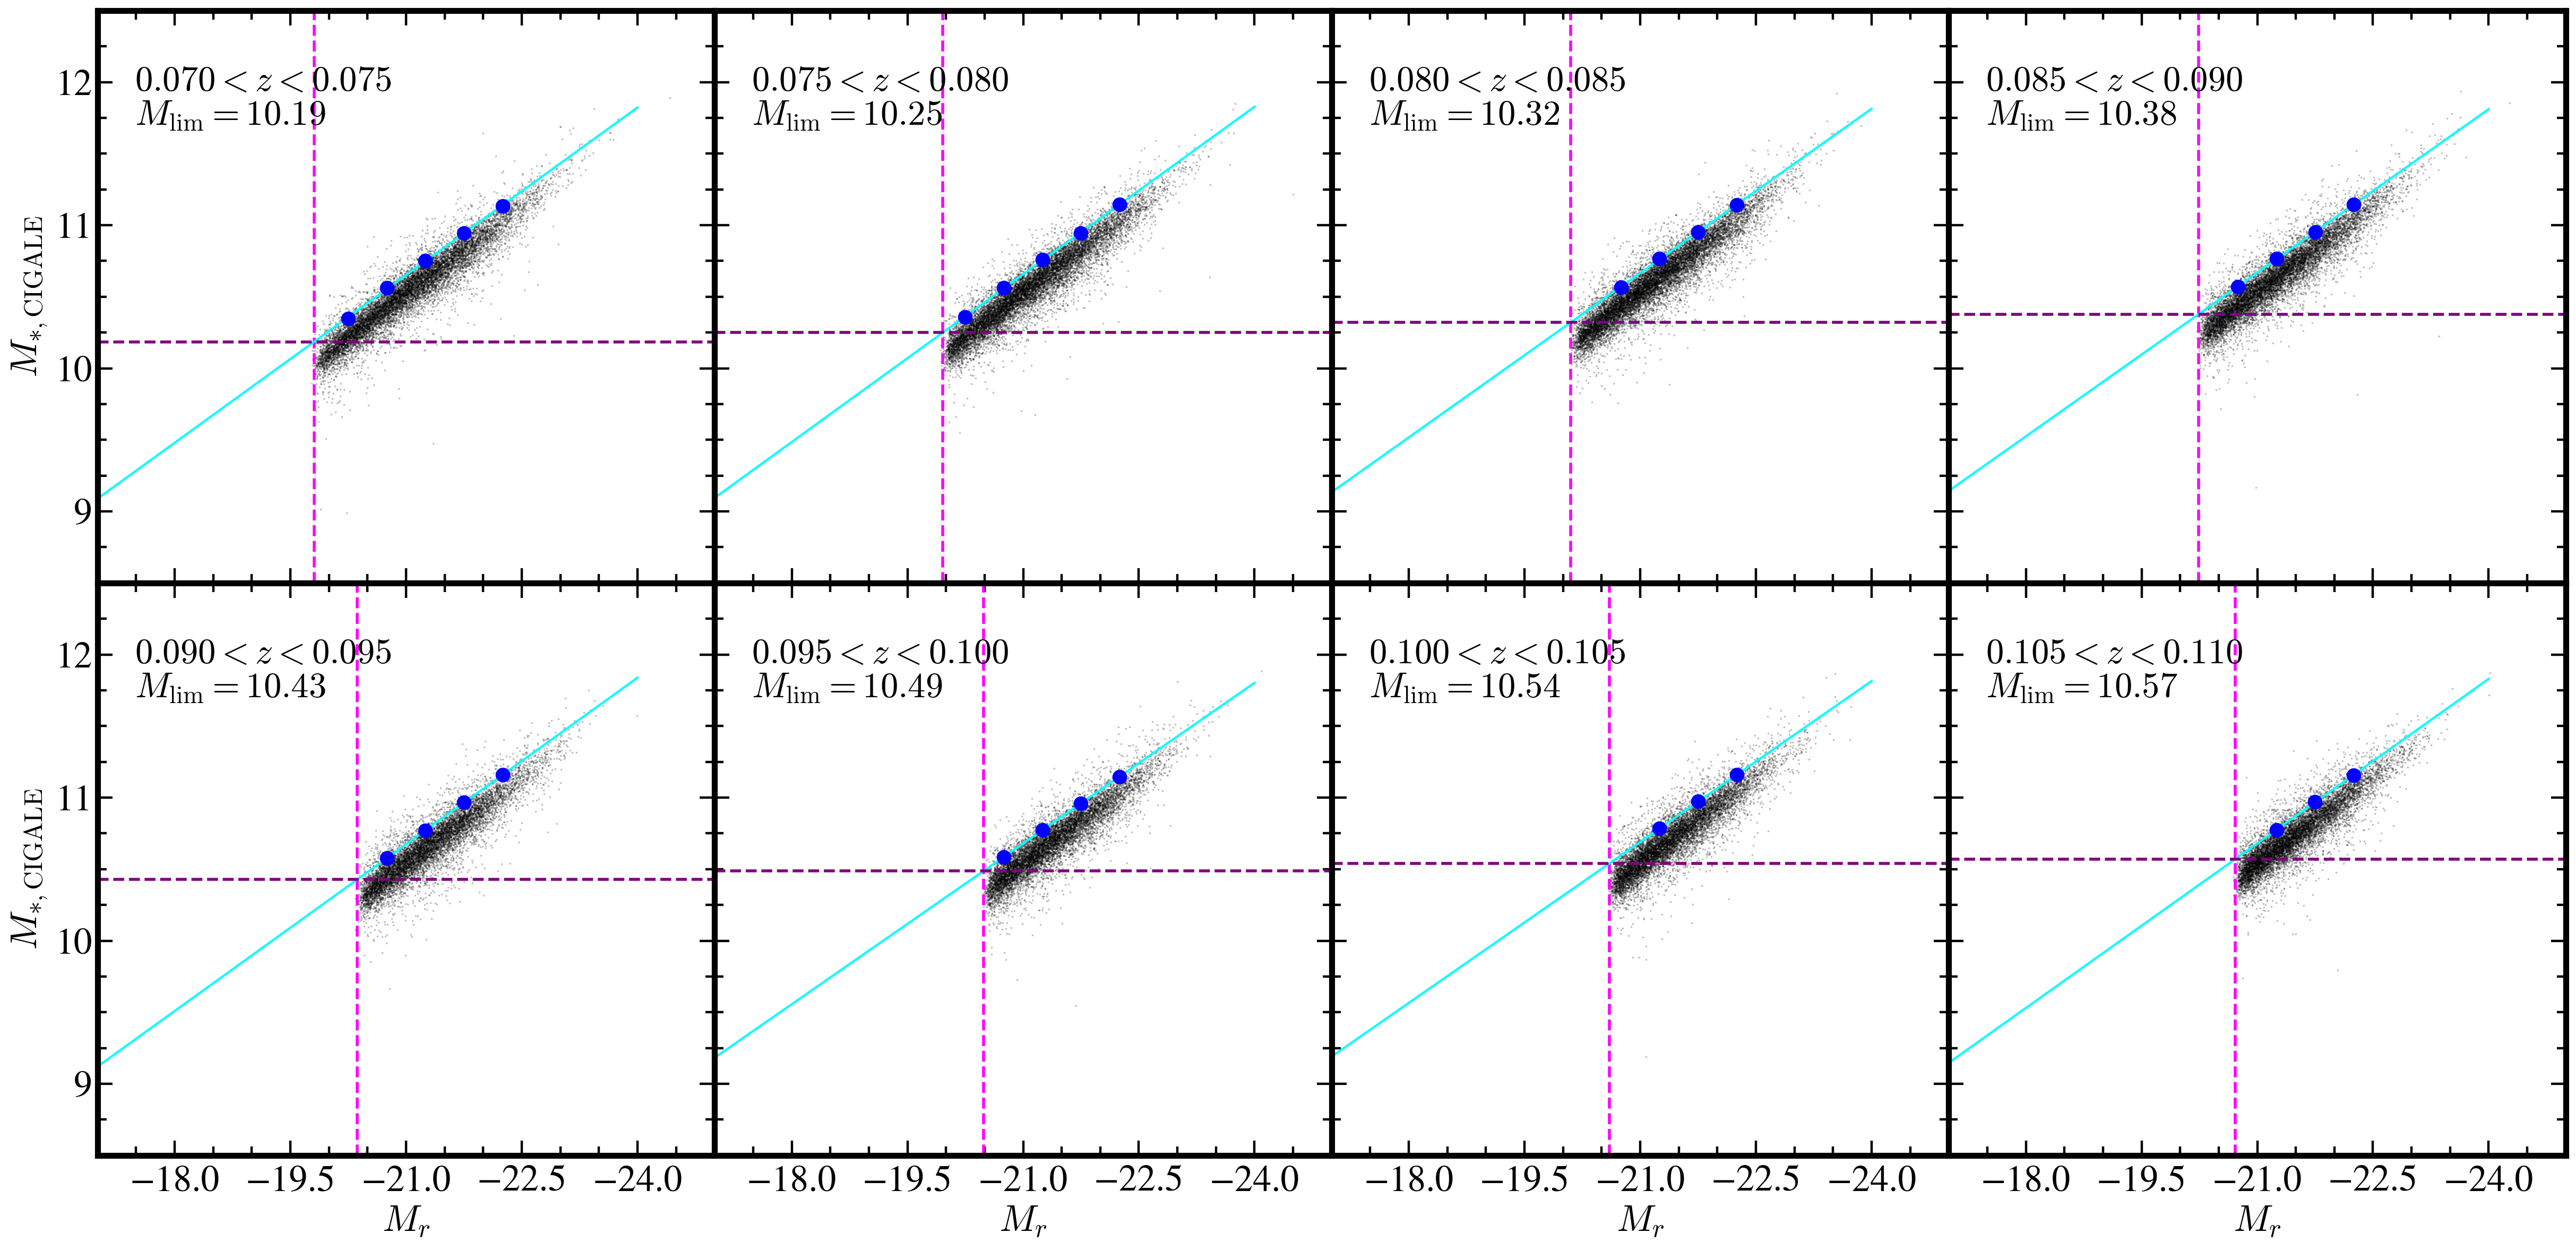

   z_center  M_star_lim
0    0.0725   10.185025
1    0.0775   10.249754
2    0.0825   10.321757
3    0.0875   10.377010
4    0.0925   10.427022
5    0.0975   10.487306
6    0.1025   10.541191
7    0.1075   10.570061


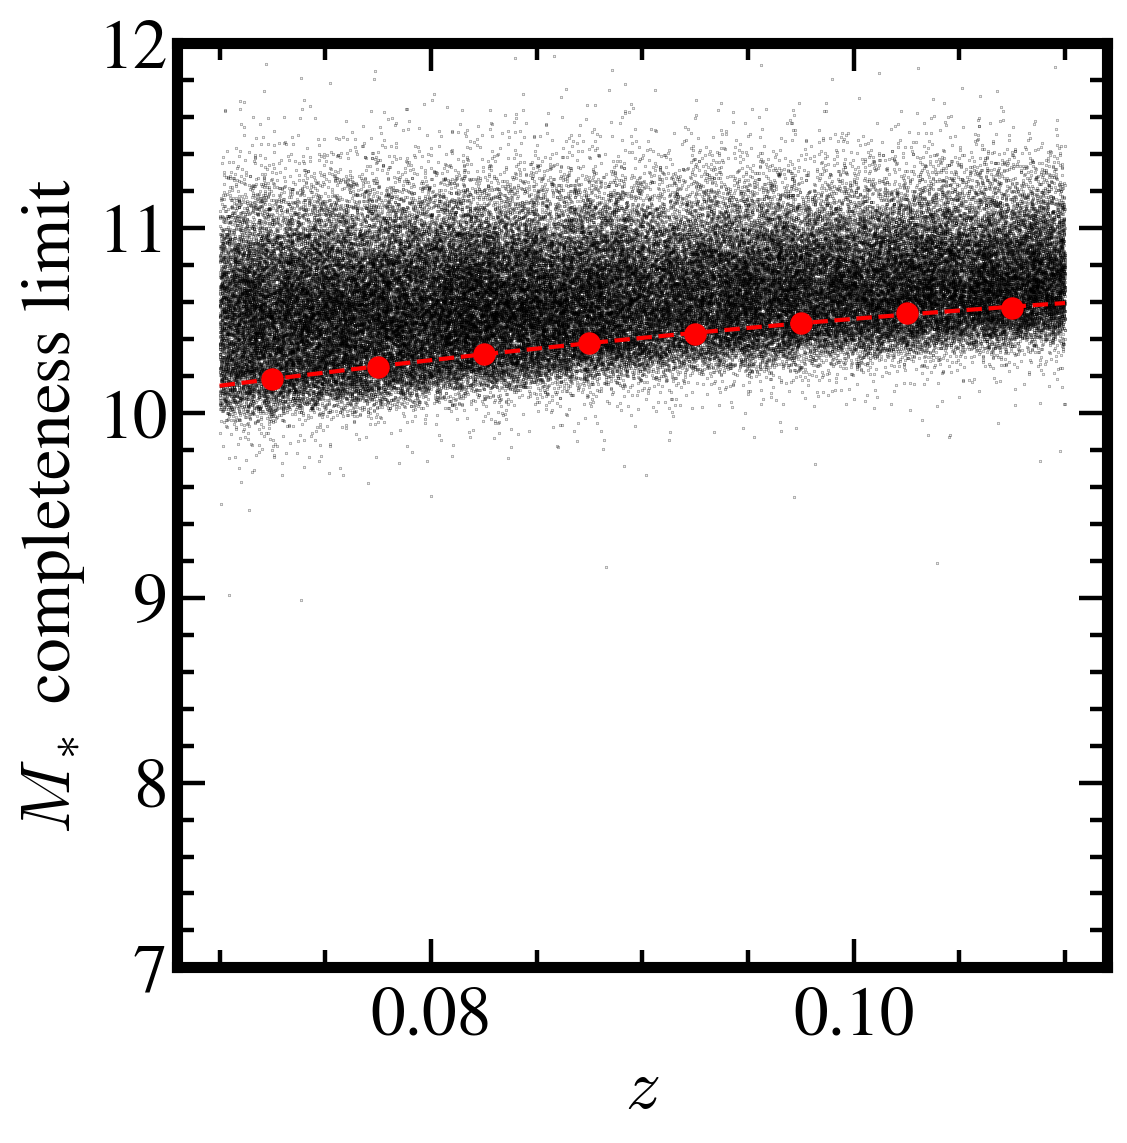

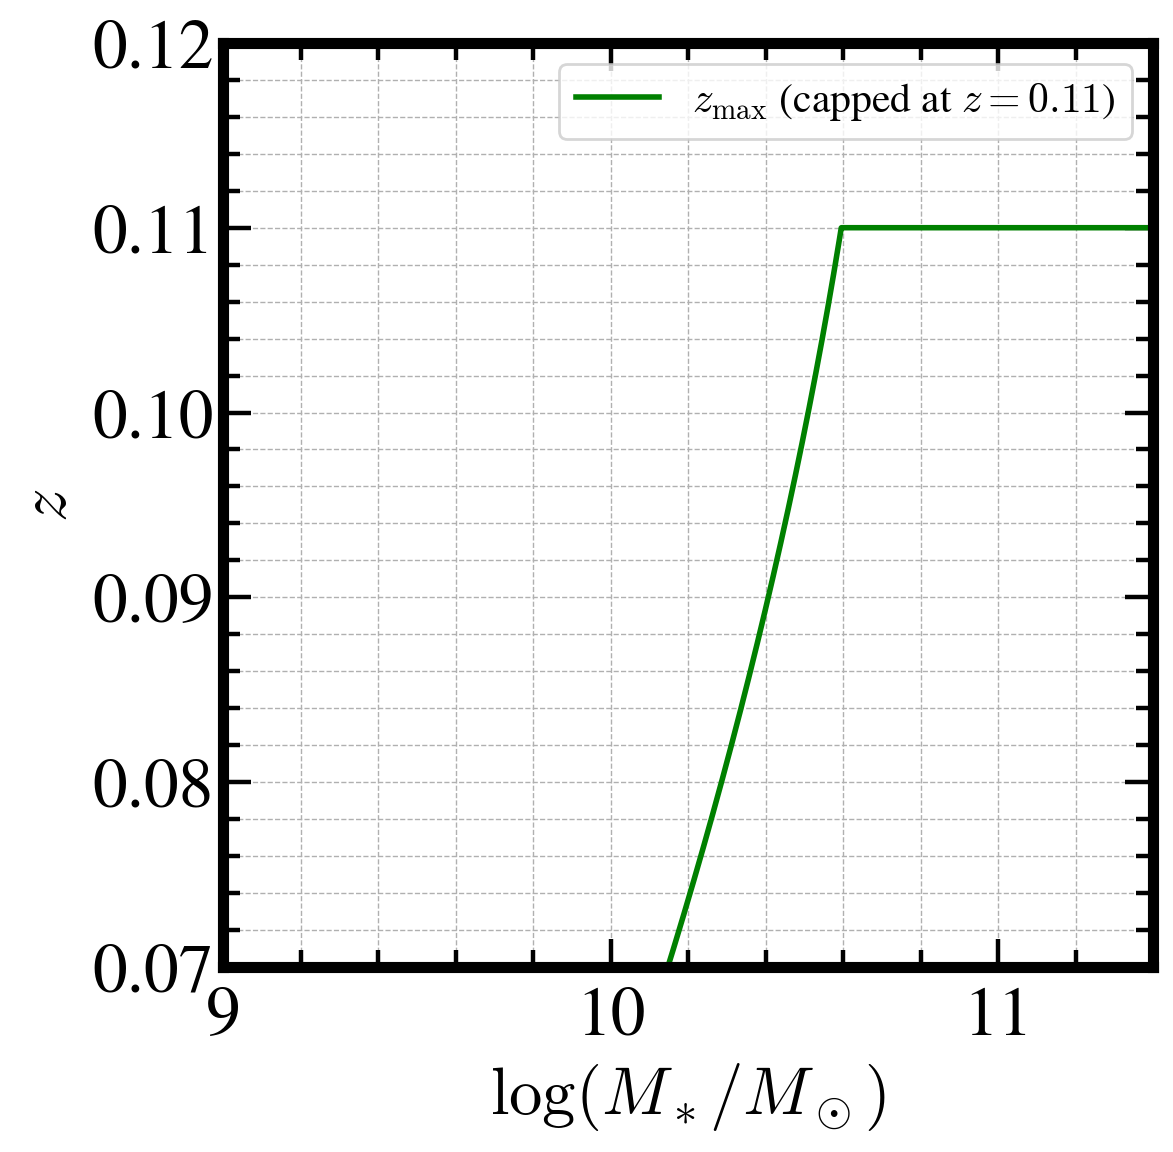

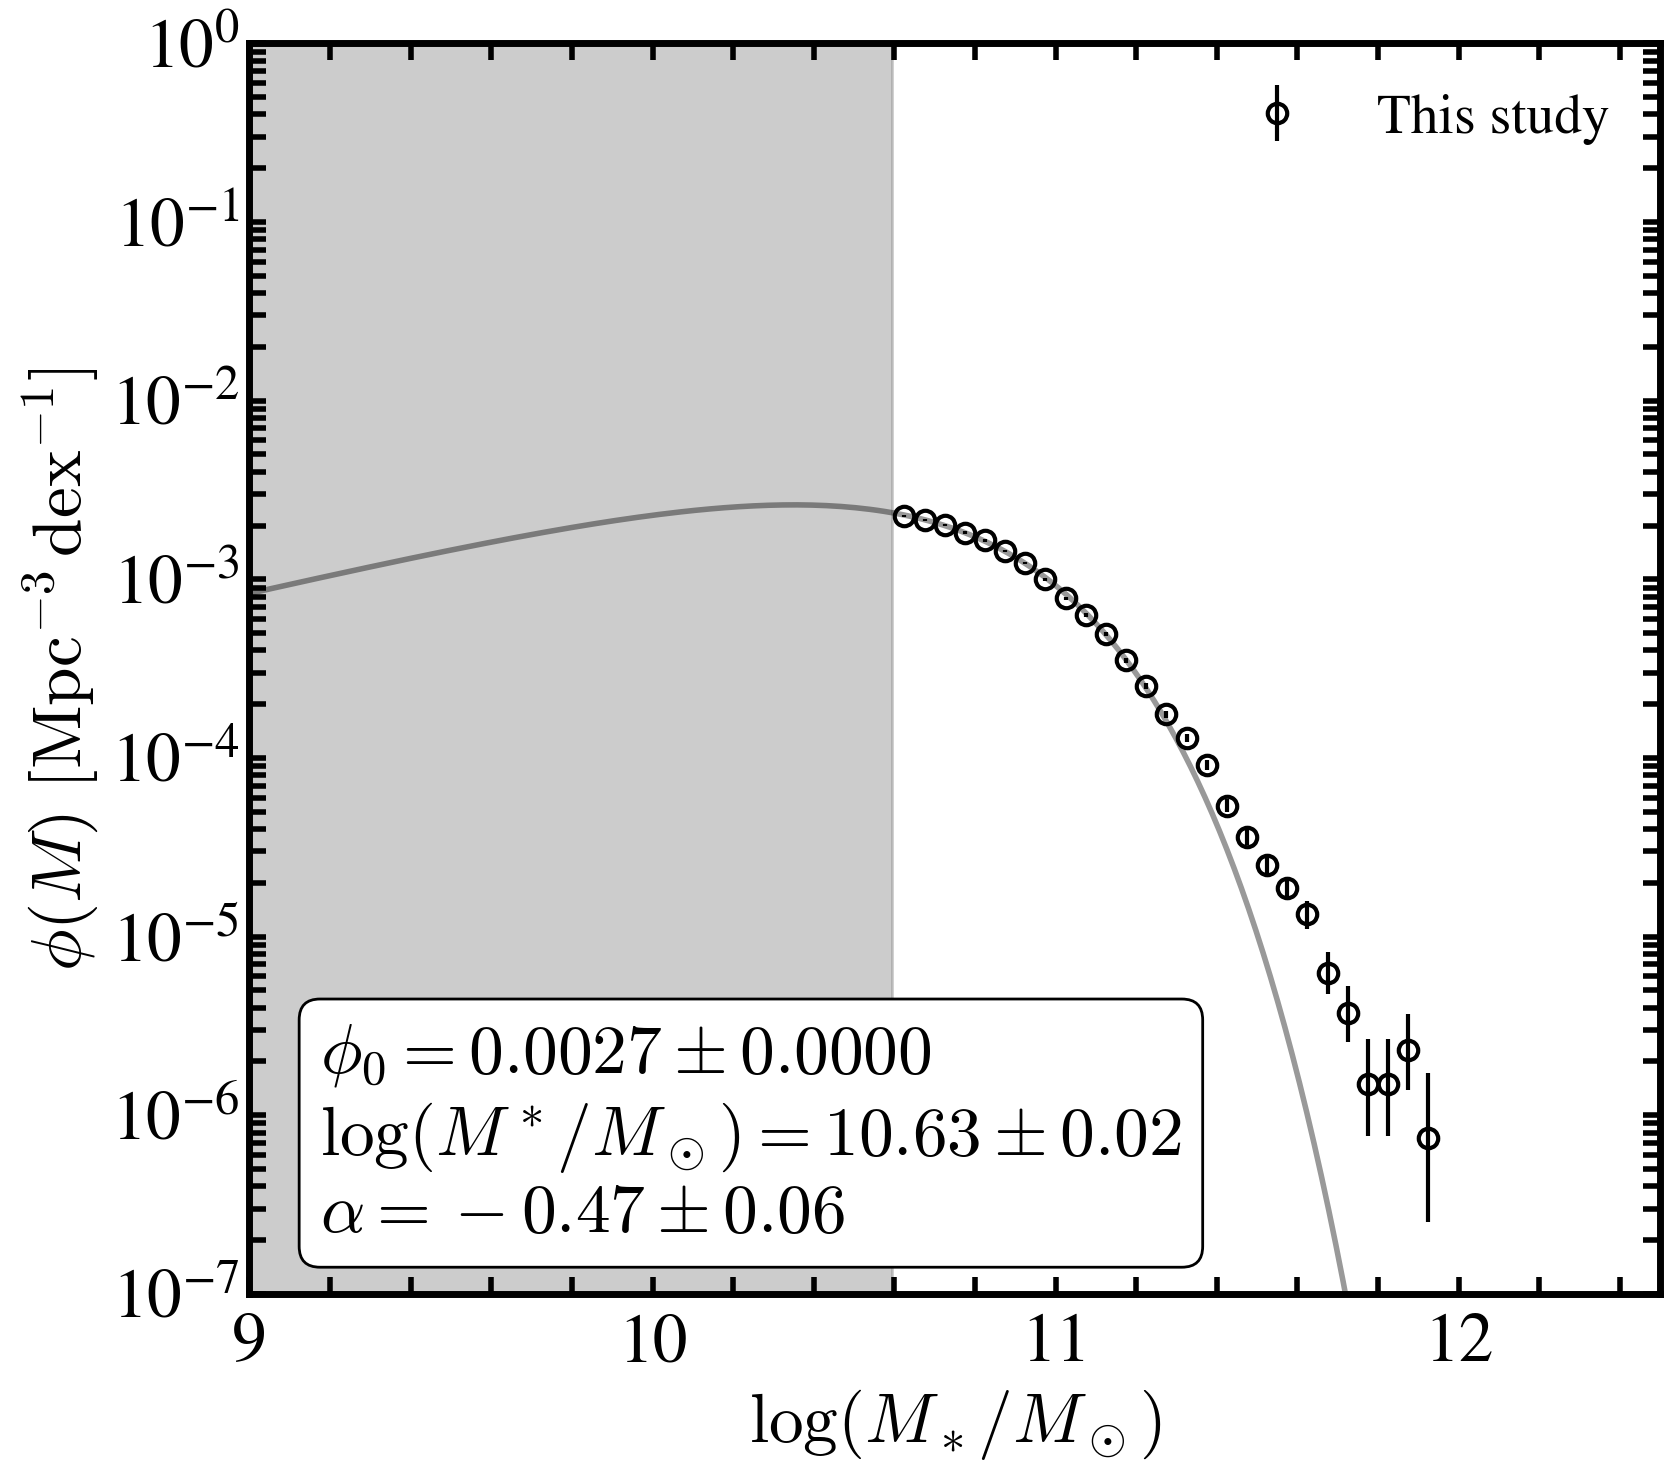

In [3]:
# ============================================================
# Quiescent Field SMF via 1/V_max
# ============================================================
# This notebook computes the stellar mass function (SMF) for
# the Quiescent subset of the field galaxy sample using
# the standard 1/V_max estimator.
# ============================================================

from numpy.polynomial.polynomial import Polynomial
from sklearn.linear_model import LinearRegression
from astropy.modeling import fitting
from astropy.modeling.models import custom_model

# ──────────────────────────────────────────────────────────────
# SECTION 1: Apparent-magnitude completeness per redshift slice
# ──────────────────────────────────────────────────────────────

z_edges    = np.arange(0.07, 0.11 + 0.005 / 2.0, 0.005)
z_slices   = [(z_edges[i], z_edges[i + 1]) for i in range(len(z_edges) - 1)]

M_APP_LIMIT = 17.77   # SDSS r-band apparent-magnitude limit

compl_records = []    # will hold (z_center, M_*,lim) per slice

fig, axes = plt.subplots(2, 4, figsize=(30, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, (z_lo, z_hi) in enumerate(z_slices):
    ax    = axes_flat[i]
    z_cen = 0.5 * (z_lo + z_hi)

    # Redshift slice
    in_slice = (df["z"] >= z_lo) & (df["z"] < z_hi)
    sub = df[in_slice]

    # Absolute-magnitude limit at the bin centre
    d_L   = cosmo.luminosity_distance(z_cen).value    # [Mpc]
    M_lim = M_APP_LIMIT - 5.0 * (np.log10(d_L * 1e6) - 1.0)

    # Restrict to a physically sensible range
    sub_filt = sub[(sub["AbsMag_r"] < M_lim) & (sub["AbsMag_r"] > -22.5)]

    # 90th-percentile M_* in 0.5-mag bins of M_r
    mag_bins = np.arange(sub_filt["AbsMag_r"].min(), sub_filt["AbsMag_r"].max(), 0.5)
    groups   = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))

    bin_mids, p90_mass = [], []
    for interval, grp in groups:
        if len(grp) == 0:
            continue
        bin_mids.append(interval.mid)
        p90_mass.append(grp["M_MASS_CIGALE"].quantile(0.90))

    bin_mids = np.array(bin_mids)
    p90_mass = np.array(p90_mass)

    # Linear fit to the 90th-percentile ridge
    reg   = LinearRegression().fit(bin_mids.reshape(-1, 1), p90_mass)
    x_fit = np.linspace(-24.0, -15.0, 100)
    y_fit = reg.predict(x_fit.reshape(-1, 1))

    # Stellar-mass completeness limit at the apparent-magnitude boundary
    M_star_lim = reg.predict([[M_lim]])[0]
    compl_records.append({"z_center": z_cen, "M_star_lim": M_star_lim})

    # ── Panel plot ──────────────────────────────────────────
    ax.scatter(sub["AbsMag_r"], sub["M_MASS_CIGALE"], color="black", s=0.01)
    ax.axvline(M_lim,      color="magenta", linestyle="--")
    ax.scatter(bin_mids, p90_mass, color="blue", s=80, zorder=3)
    ax.plot(x_fit, y_fit,  color="cyan",   lw=1.5)
    ax.axhline(M_star_lim, color="purple", linestyle="--")

    ax.set_xlim(-25.0, -17.0)
    ax.set_ylim(8.5, 12.5)
    ax.invert_xaxis()

    ax.tick_params(axis="x", which="both", direction="in",
                   top=True, labelbottom=(i // 4 == 1))
    ax.tick_params(axis="y", which="both", direction="in",
                   right=True, labelleft=(i % 4 == 0))
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(1.5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))

    if i % 4 == 0:
        ax.set_ylabel(r"$M_{\ast,\rm CIGALE}$")
    if i // 4 == 1:
        ax.set_xlabel(r"$M_r$")

    ax.text(0.06, 0.86, f"${z_lo:.3f}<z<{z_hi:.3f}$",
            transform=ax.transAxes, fontsize=24)
    ax.text(0.06, 0.80, rf"$M_{{\rm lim}}={M_star_lim:.2f}$",
            transform=ax.transAxes, fontsize=24)

for ax in axes_flat[len(z_slices):]:
    ax.axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

df_compline = pd.DataFrame(compl_records)
print(df_compline)

# ──────────────────────────────────────────────────────────────
# SECTION 2: Fit 2nd-order polynomial to completeness limits
# ──────────────────────────────────────────────────────────────

p = Polynomial.fit(df_compline["z_center"], df_compline["M_star_lim"], deg=2)
z_grid = np.linspace(0.07, 0.11, 100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["z"],                 df["M_MASS_CIGALE"],        s=0.01, color="black")
ax.scatter(df_compline["z_center"], df_compline["M_star_lim"],  s=50,   color="red")
ax.plot(z_grid, p(z_grid), "r--", lw=1.5, label="2nd-order completeness fit")
ax.set_xlabel("$z$")
ax.set_ylabel("$M_*$ completeness limit")
ax.set_ylim(7.0, 12.0)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
plt.show()

# Galaxies above the completeness curve
df_complete = df[df["M_MASS_CIGALE"] > p(df["z"])].copy()

# ──────────────────────────────────────────────────────────────
# SECTION 3: z_max per galaxy (inverse of completeness polynomial)
# ──────────────────────────────────────────────────────────────

coeffs     = p.convert().coef          # [a0, a1, a2] standard basis
a0, a1, a2 = coeffs[0], coeffs[1], coeffs[2]

Z_MIN        = 0.07
Z_SAMPLE_MAX = 0.11

# Stellar-mass completeness limit: polynomial value at the survey upper redshift z = 0.11
FIELD_SMF_MLIM = p(Z_SAMPLE_MAX)
def inverse_completeness_poly(logM: np.ndarray) -> np.ndarray:
    """
    Solve a2 z² + a1 z + (a0 − logM) = 0 for z.
    Discriminant is clipped to 0 to avoid NaN near the parabola vertex.
    """
    disc   = np.clip(a1**2 - 4.0 * a2 * (a0 - logM), 0.0, None)
    z_plus  = (-a1 + np.sqrt(disc)) / (2.0 * a2)
    z_minus = (-a1 - np.sqrt(disc)) / (2.0 * a2)
    return np.where(z_plus >= 0.0, z_plus, z_minus)

def zmax_per_galaxy(logM: np.ndarray, z_max_survey: float = Z_SAMPLE_MAX) -> np.ndarray:
    """Maximum observable redshift per galaxy, capped at the survey limit."""
    logM = np.atleast_1d(logM)
    return np.minimum(inverse_completeness_poly(logM), z_max_survey)

# Diagnostic plot: z_max(M_*)
M_diag = np.linspace(7.0, 12.0, 10_000)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(M_diag, zmax_per_galaxy(M_diag), color="green",
        label=rf"$z_{{\rm max}}$ (capped at $z={Z_SAMPLE_MAX}$)")
ax.set_xlabel(r"$\log(M_*/M_\odot)$", fontsize=24)
ax.set_ylabel("$z$",                  fontsize=24)
ax.set_xlim(9.0, 11.4)
ax.set_ylim(0.07, 0.12)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=15)
plt.show()

# ──────────────────────────────────────────────────────────────
# SECTION 4: V_max and 1/V_max SMF with Gehrels errors
# ──────────────────────────────────────────────────────────────

SURVEY_AREA_DEG2 = 8032.0
OMEGA_SR         = (SURVEY_AREA_DEG2 / 41_253.0) * 4.0 * np.pi   # [sr]

def comoving_volume(z_lo: float, z_hi: float) -> float:
    """
    Comoving survey volume between z_lo and z_hi [Mpc³],
    scaled to the survey solid angle.
    """
    d_lo = cosmo.comoving_distance(z_lo).value
    d_hi = cosmo.comoving_distance(z_hi).value
    v_sphere = (4.0 / 3.0) * np.pi * (d_hi**3 - d_lo**3)
    return v_sphere * OMEGA_SR / (4.0 * np.pi)

# Assign z_max and V_max to each galaxy in the complete sample
df_complete["z_max"] = zmax_per_galaxy(df_complete["M_MASS_CIGALE"].values, Z_SAMPLE_MAX)
df_complete["V_max"] = df_complete["z_max"].apply(lambda z: comoving_volume(Z_MIN, z))

# 1/V_max SMF in Δlog(M_*) = 0.05 bins
BIN_WIDTH   = 0.05
mass_edges  = np.arange(7.0, 13.0, BIN_WIDTH)
mass_cens   = mass_edges[:-1] + BIN_WIDTH / 2.0

phi_vals, sig_up, sig_lo = [], [], []

for m_lo, m_hi in zip(mass_edges[:-1], mass_edges[1:]):
    in_bin = (
        (df_complete["M_MASS_CIGALE"] >= m_lo) &
        (df_complete["M_MASS_CIGALE"] <  m_hi) &
        (df_complete["M_MASS_CIGALE"] >= FIELD_SMF_MLIM)
    )
    gals = df_complete.loc[in_bin].copy()

    if len(gals) == 0:
        phi_vals.append(np.nan)
        sig_up.append(np.nan)
        sig_lo.append(np.nan)
        continue

    w     = gals["w_spec"] / gals["V_max"]   # 1/V_max weights
    phi_j = w.sum() / BIN_WIDTH              # SMF value [Mpc⁻³ dex⁻¹]

    # Effective galaxy count for Poisson statistics (Gehrels 1986)
    w_eff = (w**2).sum() / w.sum()
    n_eff = w.sum() / w_eff

    # Gehrels (1986) 1σ asymmetric Poisson limits
    n_up  = n_eff + np.sqrt(n_eff + 0.75) + 1.0
    n_lo  = n_eff - np.sqrt(n_eff - 0.25)

    phi_vals.append(phi_j)
    sig_up.append(-phi_j + w_eff * n_up / BIN_WIDTH)
    sig_lo.append( phi_j - w_eff * n_lo / BIN_WIDTH)

phi_arr    = np.array(phi_vals)
sig_up_arr = np.array(sig_up)
sig_lo_arr = np.array(sig_lo)

# Convert to log space
log_phi        = np.log10(phi_arr)
log_phi_err_up = np.log10(phi_arr + sig_up_arr) - log_phi
log_phi_err_lo = log_phi - np.log10(phi_arr - sig_lo_arr)

# ──────────────────────────────────────────────────────────────
# SECTION 5: Schechter function definitions and literature params
# ──────────────────────────────────────────────────────────────

@custom_model
def schechter_1D_SMF(M, phi_0=1e-3, M_star=10.65, alpha=-1.02):
    """
    Single Schechter function in logM:
      φ = ln(10) φ₀ · 10^{(1+α)(M−M*)} · exp[−10^{(M−M*)}]
    """
    return (
        np.log(10.0) * phi_0
        * 10.0 ** ((1.0 + alpha) * (M - M_star))
        * np.exp(-10.0 ** (M - M_star))
    )

def double_schechter_1D_SMF(
    M: np.ndarray,
    phi_star1: float, phi_star2: float,
    M_star: float,
    alpha1: float,    alpha2: float,
) -> np.ndarray:
    """
    Double Schechter function in logM:
      φ = ln(10) exp[−10^{M−M*}] × [φ₁·10^{(1+α₁)(M−M*)} + φ₂·10^{(1+α₂)(M−M*)}]
    """
    ln10  = np.log(10.0)
    x     = 10.0 ** (M - M_star)
    return ln10 * np.exp(-x) * (phi_star1 * x**(1.0 + alpha1)
                                + phi_star2 * x**(1.0 + alpha2))

# Literature parameters
# Weigel+16: SDSS 0.02 < z < 0.06, h = 1 (no h³ rescaling needed for MPA masses)
weigel_params = dict(
    phi_star1=10**-3.31,
    phi_star2=10**-2.01,
    M_star=10.79,
    alpha1=-1.69,
    alpha2=-0.79,
)

# Driver+22: GAMA z < 0.1, units in h=0.7 → rescale by cosmo.h³ to Mpc⁻³
gama_params = dict(
    phi_star1=10**-2.437,
    phi_star2=10**-3.201,
    M_star=10.745,
    alpha1=-0.466,
    alpha2=-1.530,
)

# ──────────────────────────────────────────────────────────────
# SECTION 6: Fit single Schechter to this-study data
# ──────────────────────────────────────────────────────────────

# Select finite, above-completeness bins
valid_mask  = ~np.isnan(log_phi) & (mass_cens >= FIELD_SMF_MLIM)
M_fit       = mass_cens[valid_mask]
phi_fit     = 10.0 ** log_phi[valid_mask]
yerr_lo     = phi_fit - 10.0 ** (log_phi[valid_mask] - log_phi_err_lo[valid_mask])
yerr_hi     = 10.0 ** (log_phi[valid_mask] + log_phi_err_up[valid_mask]) - phi_fit

fitter  = fitting.LevMarLSQFitter()
model0  = schechter_1D_SMF()
fitted  = fitter(model0, M_fit, phi_fit)
params  = fitted.parameters
errs    = np.sqrt(np.diag(fitter.fit_info["param_cov"]))

# Model curves for plotting
M_plot    = np.linspace(7.0, 12.4, 300)
schech_m  = fitted(M_plot)
weigel_m  = double_schechter_1D_SMF(M_plot, **weigel_params)
gama_m    = double_schechter_1D_SMF(M_plot, **gama_params) / cosmo.h**3

# ──────────────────────────────────────────────────────────────
# SECTION 7: Final SMF plot
# ──────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_yscale("log")
ax.set_xlim(9.0, 12.5)
ax.set_ylim(1e-7, 1.0)

# Gray region: below completeness limit
ax.axvspan(7.0, FIELD_SMF_MLIM, color="gray", alpha=0.4)

# This study: data points
ax.errorbar(
    M_fit, phi_fit,
    yerr=[yerr_lo, yerr_hi],
    fmt="o", mfc="none", mec="black",
    ms=7, mew=1.5,
    ecolor="black", elinewidth=1.5,
    capsize=0,
    label="This study",
)

# Best-fit single Schechter curve (semi-transparent)
ax.plot(M_plot, schech_m, color="black", linestyle="-", lw=2, alpha=0.4)

# Annotate fitted Schechter parameters
param_text = (
    rf"$\phi_0 = {params[0]:.4f} \pm {errs[0]:.4f}$"   "\n"
    rf"$\log(M^*/M_\odot) = {params[1]:.2f} \pm {errs[1]:.2f}$"   "\n"
    rf"$\alpha = {params[2]:.2f} \pm {errs[2]:.2f}$"
)
ax.annotate(
    param_text,
    xy=(0.05, 0.05), xycoords="axes fraction",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
)

# Axes formatting
ax.set_xlabel(r"$\log(M_*/M_\odot)$")
ax.set_ylabel(r"$\phi(M)\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
ax.tick_params(axis="both", which="both", direction="in",
               top=True, right=True, width=2, length=6)
ax.minorticks_on()
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.legend(fontsize=20, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

In [4]:
# Collect SMF measurements (linear φ and asymmetric errors) into a table
smf_data = pd.DataFrame({
    "logM": M_fit,                  # bin centers [log(M*/Msun)]
    "phi_Mpc-3_dex-1": phi_fit,     # SMF value φ(M) in linear units
    "phi_err_low": yerr_lo,         # lower 1σ error in linear units
    "phi_err_up": yerr_hi           # upper 1σ error in linear units
})

# Save to CSV (no index) and report where it was written
output_csv = "FieldSMF_quiescent.csv"
smf_data.to_csv(output_csv, index=False)
print(f"Saved quiescent field SMF to '{output_csv}'")

Saved quiescent field SMF to 'FieldSMF_quiescent.csv'
